# Olist: Delivery Time Prediction EDA

## 1. Data loading & filtering

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [4]:
delivered = orders[orders['order_status'] == "delivered"].copy()
delivered = delivered.dropna(subset = ["order_delivered_customer_date"])

In [5]:
print(orders.shape)
print(delivered.shape)

(99441, 8)
(96470, 8)


## 2. Target: delivery_days

In [6]:
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

In [7]:
delivered['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [8]:
print("Same-day delivery:", (delivered['delivery_days'] <= 0).sum())
delivered[delivered['delivery_days'] <= 0]

Same-day delivery: 13


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
395,38c1e3d4ed6a13cd0cf612d4c09766e9,18c934f4cdc994cd04eb13bce3f47a18,delivered,2018-02-02 15:26:38,2018-02-02 16:00:16,2018-02-03 01:18:26,2018-02-03 15:05:56,2018-02-20 00:00:00,0
735,d3ca7b82c922817b06e5ca21165c5ea2,d23df2c6c3e51d875f458d123b2b3c90,delivered,2017-11-16 13:54:08,2017-11-16 14:08:23,2017-11-16 20:56:53,2017-11-17 13:49:40,2017-11-29 00:00:00,0
31522,1d893dd7ca5f77ebf5f59f0d2017eee0,b19da0df0271e8a3553e3670f86aeab5,delivered,2017-06-19 08:19:45,2017-06-19 08:30:20,2017-06-19 13:32:04,2017-06-19 21:07:52,2017-06-30 00:00:00,0
37753,21a8ffca665bc7a1087d31751a7b7cbc,225aed9e773953084b09cf496c2be05a,delivered,2017-05-31 12:00:35,2017-05-31 13:07:28,2017-05-31 12:43:47,2017-06-01 10:28:24,2017-06-13 00:00:00,0
38792,f3c6775ba3d2d9fe2826f93b71f12008,6aef84c09844a371d82a49152c550b95,delivered,2017-07-04 11:37:47,2017-07-04 11:50:21,2017-07-04 13:53:13,2017-07-05 08:09:26,2017-07-17 00:00:00,0
41803,434cecee7d1a65fc65358a632b6f725f,922a46283625e9c096bfd998913c470c,delivered,2017-05-29 13:21:46,2017-05-29 13:30:24,2017-05-29 14:54:51,2017-05-30 08:06:56,2017-06-19 00:00:00,0
48767,f349cdb62f69c3fae5c4d7d3f3a4a185,c5e200d485ae35a7036cc2e7c1d8ea81,delivered,2018-06-28 14:34:48,2018-06-28 14:50:48,2018-06-28 18:08:00,2018-06-29 14:12:18,2018-07-12 00:00:00,0
48878,d5fbeedc85190ba88580d6f82d1d5ed3,344423c2e26d47d2b6d3dd363a89e812,delivered,2017-05-15 11:50:53,2017-05-15 12:12:07,2017-05-15 12:52:34,2017-05-16 10:21:52,2017-05-24 00:00:00,0
51067,e65f1eeee1f52024ad1dcd03447f7482,198f511b5a75bf936a96f1d4769e3974,delivered,2018-05-18 15:03:19,2018-05-18 15:15:37,2018-05-18 15:00:00,2018-05-19 12:28:30,2018-05-29 00:00:00,0
69291,79e324907160caea526fd8b94389dbbc,331d79b67223ee7e5cd31d3e03e4cfcc,delivered,2018-06-18 12:59:42,2018-06-18 13:16:46,2018-06-18 14:52:00,2018-06-19 12:43:27,2018-06-28 00:00:00,0


Checked timestamps: these are real deliveries under 24h. Kept.

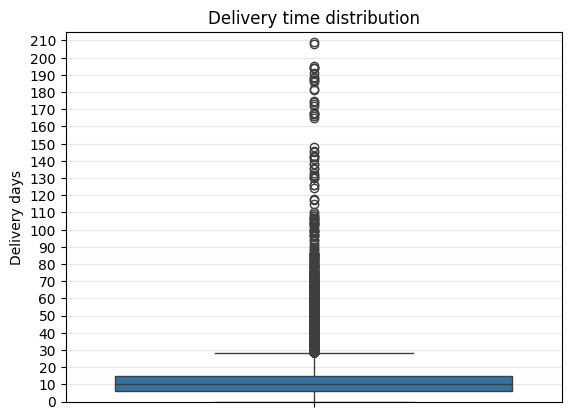

In [9]:
sns.boxplot(delivered['delivery_days'])
plt.ylabel("Delivery days")
plt.title("Delivery time distribution")
plt.ylim(0, 215)
plt.yticks(range(0, 215, 10))
plt.show()

In [10]:
for threshold in [30, 45, 60, 100]:
    mask = delivered['delivery_days'] >= threshold
    print(f"Orders with >= {threshold} days: {mask.sum()}, ({mask.mean()*100:.2f}%)")


Orders with >= 30 days: 4550, (4.72%)
Orders with >= 45 days: 1092, (1.13%)
Orders with >= 60 days: 306, (0.32%)
Orders with >= 100 days: 64, (0.07%)


In [11]:
delivered['delivery_days'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])

0.500     10.0
0.900     23.0
0.950     29.0
0.990     46.0
0.999     83.0
1.000    209.0
Name: delivery_days, dtype: float64

In [12]:
clean = delivered[(delivered['delivery_days'] < 60) & (delivered['delivery_days'] >= 0)].copy()
clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96164 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  object        
 8   delivery_days                  96164 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 7.3+ MB


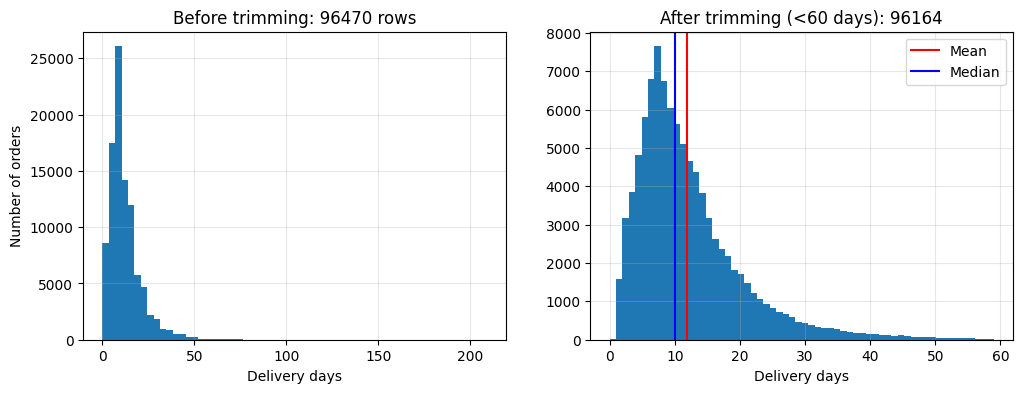

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delivered['delivery_days'], bins=60)
axes[0].set_title(f"Before trimming: {len(delivered)} rows")
axes[0].set_xlabel("Delivery days")
axes[0].set_ylabel("Number of orders")

axes[1].hist(clean['delivery_days'], bins=60)
axes[1].axvline(clean['delivery_days'].mean(), color ='red', label='Mean')
axes[1].axvline(clean['delivery_days'].median(), color = 'blue', label='Median')
axes[1].legend()
axes[1].set_title(f"After trimming (<60 days): {len(clean['delivery_days'])}")
axes[1].set_xlabel("Delivery days")

plt.show()

Threshold 60 days: cutting at 30 would remove slow deliveries, 60 removes only 306 orders. Distribution shape unchanged.

In [14]:
clean['purchase_month'] = clean['order_purchase_timestamp'].dt.month
clean['purchase_day_of_week'] = clean['order_purchase_timestamp'].dt.dayofweek

In [15]:
clean.groupby('purchase_month')['delivery_days'].mean()

purchase_month
1     13.135733
2     15.216495
3     14.473451
4     11.635222
5     10.771887
6      9.543639
7      9.431439
8      8.625498
9     11.286680
10    11.717515
11    14.394791
12    14.649663
Name: delivery_days, dtype: float64

In [16]:
clean.groupby('purchase_day_of_week')['delivery_days'].mean()

purchase_day_of_week
0    11.289760
1    11.387103
2    11.695354
3    12.069052
4    12.870216
5    12.660806
6    11.280183
Name: delivery_days, dtype: float64

In [17]:
clean['purchase_year'] = clean['order_purchase_timestamp'].dt.year
clean.groupby('purchase_year')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_year,,
2016,18.662879,264
2017,12.267084,43286
2018,11.486372,52614


## 3. Baseline: Olist's own estimate

In [18]:
clean['order_estimated_delivery_date'] = pd.to_datetime(clean['order_estimated_delivery_date'])
clean['estimated_days'] = (
    clean['order_estimated_delivery_date'] - clean['order_purchase_timestamp']
).dt.days
clean[['estimated_days', 'delivery_days']].corr()

,estimated_days,delivery_days
estimated_days,1.00000,0.41955
delivery_days,0.41955,1.00000


In [19]:
clean['estimation_error'] = clean['estimated_days'] - clean['delivery_days']
clean['estimation_error'].describe()

count    96164.000000
mean        11.495861
std          9.227664
min        -50.000000
25%          7.000000
50%         12.000000
75%         16.000000
max        146.000000
Name: estimation_error, dtype: float64

<Axes: ylabel='estimation_error'>

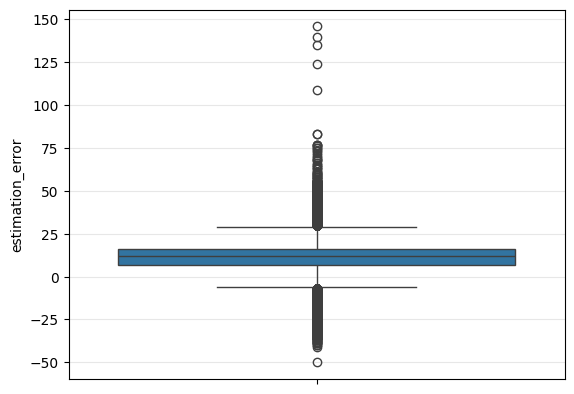

In [20]:
sns.boxplot(clean['estimation_error'])

In [21]:
print(f"Error over 100 days:", (clean['estimation_error'] >= 100).sum())

Error over 100 days: 5


In [22]:
print("Late deliveries (error < 0):", (clean['estimation_error'] < 0).sum())

Late deliveries (error < 0): 7005


In [23]:
print("MAE Olist estimate:", clean['estimation_error'].abs().mean().round(2))
print("MAE naive baseline: ", (clean['delivery_days'] - clean['delivery_days'].mean()).abs().mean().round(2))

MAE Olist estimate: 12.67
MAE naive baseline:  6.14


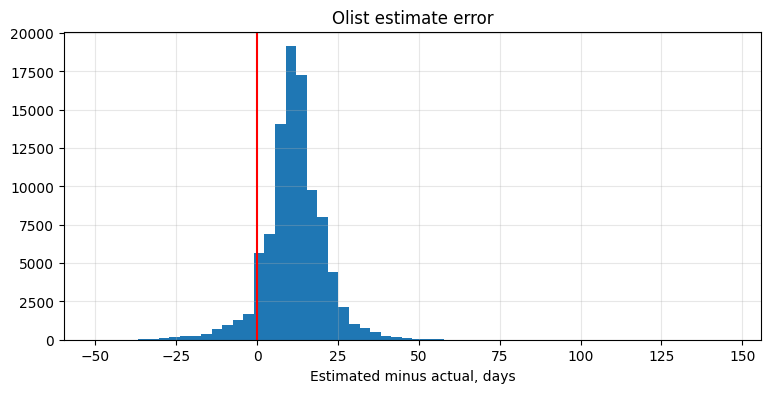

In [24]:
clean['estimation_error'].hist(bins=60, figsize=(9,4))
plt.axvline(0, color='red')
plt.xlabel('Estimated minus actual, days')
plt.title('Olist estimate error')
plt.savefig('../images/olist_estimate_error.png', dpi=150, bbox_inches='tight')
plt.show()

Olist's estimate is built to avoid being late, not to be accurate.

In [25]:
print("Rows: ", len(clean))
print("Unique order ID: ", clean['order_id'].nunique())

Rows:  96164
Unique order ID:  96164


## 4. Time features

In [26]:
clean['is_weekend'] = (clean['purchase_day_of_week'] >= 5).astype(int)

In [27]:
clean.groupby('is_weekend')['delivery_days'].mean()

is_weekend
0    11.833752
1    11.936974
Name: delivery_days, dtype: float64

In [28]:
clean = clean.drop(columns='is_weekend')

is_weekend: no effect (11.83 vs 11.94). Dropped.

In [29]:
clean['purchase_hour'] = clean['order_purchase_timestamp'].dt.hour
clean.groupby('purchase_hour')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_hour,,
0,12.379922,2311
1,12.031887,1129
2,11.809717,494
3,11.841699,259
4,11.123153,203
5,11.521978,182
6,11.429175,473
7,11.355109,1194
8,11.512759,2900


In [30]:
clean = clean.drop(columns='purchase_hour')

purchase_hour: noise. "Fastest" hour 4am has 203 orders vs 6454 at 4pm. Daytime hours all within 11.6-12.1. Also dropped.

## 5. Geography: states & same_state

In [31]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

In [32]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [33]:
customers['customer_city'].value_counts().head(20)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
sao jose dos campos        691
fortaleza                  654
sorocaba                   633
recife                     613
florianopolis              570
Name: count, dtype: int64

In [34]:
clean = clean.merge(customers[['customer_id', 'customer_state', 'customer_city']], on = 'customer_id', how='left')
print(clean.shape)

(96164, 16)


In [35]:
clean.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,0,2017,15,7,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,1,2018,19,6,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2,2018,26,17,GO,vianopolis


In [36]:
clean.groupby('customer_state')['delivery_days'].agg(['mean','median' ,'count']).sort_values('mean')

,mean,median,count
customer_state,,,
SP,8.190851,7.0,40440
PR,11.449054,10.0,4917
MG,11.470510,10.0,11343
DF,12.459577,11.0,2078
RJ,14.358606,11.0,12253
SC,14.366949,12.0,3540
RS,14.675291,13.0,5334
ES,14.886707,13.0,1986
GO,14.921147,13.0,1953


customer_state: 8.19 (SP) to 25.21 (AM). North is slow and uniform. RJ stands out: median 11 like MG, but mean 14.36

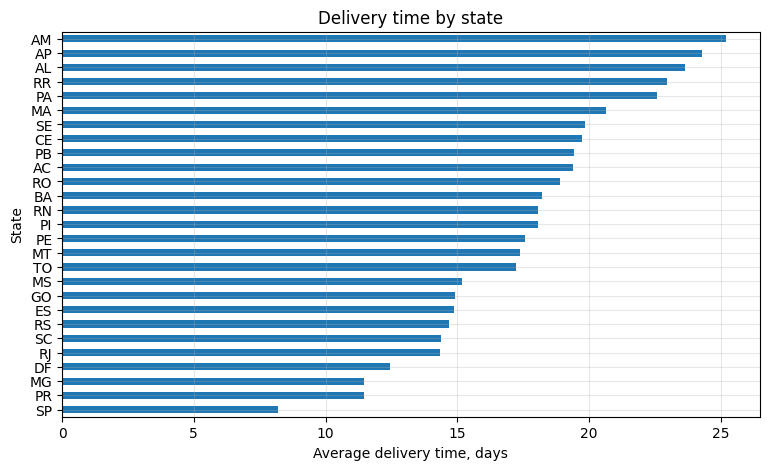

In [37]:
state_stats = (clean.groupby('customer_state')['delivery_days'].mean().sort_values())

state_stats.plot.barh(figsize=(9,5))
plt.xlabel("Average delivery time, days")
plt.ylabel("State")
plt.title("Delivery time by state")
plt.show()


## 6. Product features

In [38]:
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [39]:
items_agg = items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    quantity_items = ('order_item_id', 'count'),
    n_sellers = ('seller_id', 'nunique')
).reset_index()

In [40]:
print(items_agg.shape)

(98666, 5)


In [41]:
clean = clean.merge(items_agg, on='order_id', how='left')
print(clean.shape)

(96164, 20)


In [42]:
clean.info()
clean.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error,customer_state,customer_city,total_price,total_freight,quantity_items,n_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,0,2017,15,7,SP,sao paulo,29.99,8.72,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,1,2018,19,6,BA,barreiras,118.70,22.76,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2,2018,26,17,GO,vianopolis,159.90,19.22,1,1


In [43]:
clean['n_sellers'].value_counts()

n_sellers
1    94889
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

For seller_state I take the first seller of each order. Almost all orders have one seller anyway.

In [44]:
first_item = items.sort_values('order_item_id').drop_duplicates('order_id')[['order_id', 'seller_id', 'product_id']]
clean = clean.merge(first_item, on='order_id', how='left')
print(clean.shape)

(96164, 22)


In [45]:
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
clean = clean.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(clean.shape)

(96164, 23)


In [46]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

In [47]:
clean['same_state'] = (clean['customer_state'] == clean['seller_state']).astype(int)
clean.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,14.38,61506
1,7.38,34658


In [48]:
sp = clean[clean['customer_state'] == 'SP']
sp.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,10.73,9743
1,7.38,30697


same_state: 14.38 vs 7.38 overall. But almost all same_state=1 orders are from SP, which is the fastest state anyway. Within SP the gap drops to 3.35 days. Kept.

In [49]:
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
products.info()
products.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [50]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [51]:
print(products['product_id'].is_unique)

True


In [52]:
products_cols = ["product_id",'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

clean = clean.merge(products[products_cols], on = 'product_id', how='left')

In [53]:
print(clean.shape)

(96164, 29)


In [54]:
clean['product_category_name'] = clean['product_category_name'].fillna('unknown')

In [55]:
clean.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_days                     0
purchase_month                    0
purchase_day_of_week              0
purchase_year                     0
estimated_days                    0
estimation_error                  0
customer_state                    0
customer_city                     0
total_price                       0
total_freight                     0
quantity_items                    0
n_sellers                         0
seller_id                         0
product_id                        0
seller_state                      0
same_state                        0
product_category_name             0
product_weight_g                 16
product_length_cm                16
product_height_cm           

Not features: order_approved_at, order_delivered_carrier_date, estimated_days, estimation_error (baseline).

In [56]:
clean['volume_cm3'] = (clean['product_width_cm'] *
                      clean['product_height_cm'] *
                      clean['product_length_cm'])

In [57]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

## 7. Correlations & conclusions

In [58]:
num_cols = ['delivery_days', 'total_price', 'total_freight', 'quantity_items', 'volume_cm3', 'product_weight_g', 'same_state']
clean[num_cols].corr()['delivery_days'].sort_values(ascending=False).round(3)

delivery_days       1.000
total_freight       0.181
product_weight_g    0.083
volume_cm3          0.072
total_price         0.056
quantity_items     -0.019
same_state         -0.401
Name: delivery_days, dtype: float64

In [59]:
top_cities = clean.customer_city.value_counts().head(30).index
clean['customer_city_grouped'] = 'other'
mask = clean['customer_city'].isin(top_cities)
clean.loc[mask, 'customer_city_grouped'] = clean.loc[mask, 'customer_city']

In [60]:
print(clean['customer_state'].nunique())
print(clean['seller_state'].nunique())
print(clean['product_category_name'].nunique())

27
22
74


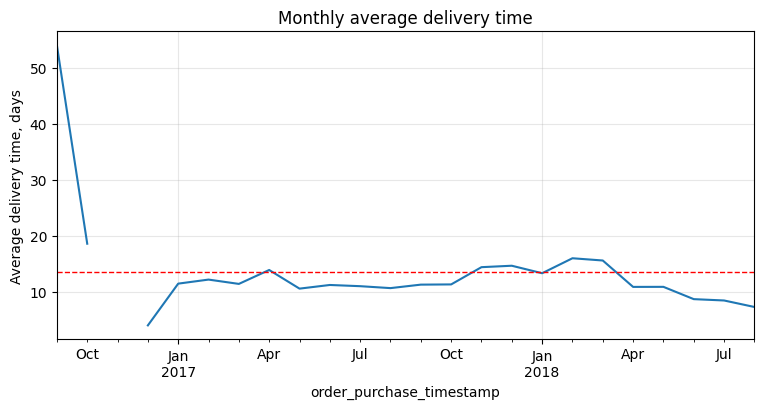

In [61]:
monthly = (clean.set_index('order_purchase_timestamp').resample('ME')['delivery_days'].mean())

monthly.plot(figsize=(9,4))
plt.axhline(monthly.mean(), color = 'red', linestyle = '--', linewidth=1)
plt.ylabel("Average delivery time, days")
plt.title("Monthly average delivery time")
plt.show()

2016: only 264 orders, monthly averages are noise so ignore.
2017-2018: 10-16 days, seasonal rise in winter.
H2 2018: fastest period, 7-9 days.

Delivery time drifts over the period so split must be time-based, and baseline MAE must be recalculated on the test set.

**EDA summary.** Geography is the strongest signal. Delivery time by state ranges from 8.2 to 25.2 days. Numeric features are weak — the best one is total_freight with correlation 0.18. Two baselines to beat: naive mean (MAE 6.14) and Olist estimate (MAE 12.67). Both numbers need to be recalculated on the test set.

## 8. Geo distance

In [62]:
geo = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
print(geo.shape)
print(geo['geolocation_zip_code_prefix'].nunique())

(1000163, 5)
19015


In [63]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [64]:
geo_agg = (geo.groupby('geolocation_zip_code_prefix')
           .agg(lat=('geolocation_lat', 'median'),
           lng=('geolocation_lng', 'median')))

print(geo_agg.shape)

(19015, 2)


In [65]:
def haversine_km (lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

In [66]:
clean = clean.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left')

In [67]:
clean = clean.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={'lat':  'customer_lat', 'lng': 'customer_lng'})

print(clean.shape)

(96164, 34)


In [68]:
clean = clean.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

clean = clean.merge(
    geo_agg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={'lat': 'seller_lat', 'lng': 'seller_lng'})

print(clean.shape)

(96164, 37)


In [69]:
print(clean[['customer_lat', 'customer_lng']].isnull().sum())
print(clean[['seller_lat', 'seller_lng']].isnull().sum())

customer_lat    261
customer_lng    261
dtype: int64
seller_lat    215
seller_lng    215
dtype: int64


In [70]:
clean['distance_km'] = haversine_km(
    clean['customer_lat'], clean['customer_lng'],
    clean['seller_lat'], clean['seller_lng']
)

print(clean['distance_km'].describe())
print("NaN distance: ", clean['distance_km'].isnull().sum())

count    95689.000000
mean       599.296406
std        592.845920
min          0.000000
25%        183.380634
50%        433.104758
75%        796.690760
max       8677.859564
Name: distance_km, dtype: float64
NaN distance:  475


In [71]:
print((clean['distance_km'] > 4500).sum())

4


In [72]:
clean[clean['distance_km'] > 4500]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,...,product_width_cm,volume_cm3,customer_city_grouped,customer_zip_code_prefix,customer_lat,customer_lng,seller_zip_code_prefix,seller_lat,seller_lng,distance_km
703,8ad3f1d0f96992e43566c4c82c9f6c58,948b29e24216a05fea13a18d8db45ea5,delivered,2018-07-17 21:25:29,2018-07-17 21:35:17,2018-07-18 13:08:00,2018-08-14 04:04:40,2018-08-03,27,7,...,41.0,53751.0,other,83252,42.184003,-8.723762,89288,-26.231306,-49.412569,8677.859564
5456,acdbc7396e191931c263db11af241d62,816fa7cf00e01aaf19c7ad215b049c9b,delivered,2017-11-05 19:54:45,2017-11-07 07:30:48,2017-11-08 16:22:45,2017-12-04 21:04:22,2017-12-14,29,11,...,18.0,4374.0,other,68275,41.146203,-8.577855,14110,-21.258652,-47.813946,8032.929717
69468,897ec6416d50126a9061626f0fc2d658,2dd769df72fbd8448297d18c48df7b92,delivered,2017-04-20 15:05:38,2017-04-20 15:21:31,2017-04-24 07:52:21,2017-05-18 08:06:47,2017-05-22,27,4,...,20.0,640.0,other,46560,13.001420,-23.583939,5849,-23.652443,-46.755492,4791.606339
93623,4d5abe7999d76d1fb6237d3677706af0,88aac7b0942dcdb41ebabf7811b106fc,delivered,2017-11-23 18:13:30,2017-11-23 18:55:39,2017-11-28 20:07:50,2017-12-19 08:58:58,2018-01-04,25,11,...,18.0,4374.0,other,68275,41.146203,-8.577855,14110,-21.258652,-47.813946,8032.929717


In [73]:
clean.loc[clean['distance_km']>4500, 'distance_km'] = None

In [74]:
print("NaN distance in parquet:", clean['distance_km'].isnull().sum())

NaN distance in parquet: 479


In [75]:
clean.to_parquet('../data/clean/clean.parquet', engine='fastparquet')

*distance_km: haversine between customer and seller zip centroids. 479 orders get NaN: 475 have no coordinates, 4 have broken geo data pointing outside Brazil. Imputation happens in the modeling notebook on train data only.*